<a href="https://colab.research.google.com/github/reza-pishva/RNN-projects/blob/main/Clustering/Lube%20Oil%20System/DBSCAN/clustering_lube_oil_g12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, silhouette_samples
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Lambda, Layer
from tensorflow.keras.losses import mse
from sklearn.decomposition import PCA
from tensorflow.keras import backend as K
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import scipy.cluster.hierarchy as sch
import warnings # Ignore specific warnings
warnings.filterwarnings("ignore")

In [73]:
df1 = pd.read_excel('output_lube_oil_g12.xlsx')

In [74]:
df1.head(10)

,AssetID_8346,AssetID_9286,AssetID_8341,AssetID_9287,AssetID_8343,AssetID_8344,AssetID_8342,date
0,7.80,8.0,0.24,1.35,67.0,-200.0,12.3,2021-04-01 10:20:09
1,0.00,7.4,0.35,1.42,44.0,-220.0,NaN,2021-05-18 12:57:33
2,0.00,7.4,0.56,1.41,42.0,-220.0,10.7,2021-05-18 15:44:38
3,0.00,7.4,0.11,1.41,41.0,-220.0,10.7,2021-05-18 18:52:45
4,0.00,7.4,0.15,1.41,40.0,-220.0,10.7,2021-05-18 21:46:38
5,0.00,7.4,0.18,1.42,36.0,-230.0,10.7,2021-05-19 00:52:08
6,7.50,0.0,0.18,34.00,35.0,-200.0,10.8,2021-05-19 04:20:24
7,1.35,7.6,0.18,8.10,39.0,-240.0,11.3,2021-05-19 07:18:58
8,0.00,0.0,0.27,1.48,42.0,-240.0,11.3,2021-05-20 06:47:20
9,0.00,0.0,0.23,1.48,44.0,-240.0,11.3,2021-05-24 08:20:55


In [75]:
df1.columns

Index(['AssetID_8346', 'AssetID_9286', 'AssetID_8341', 'AssetID_9287',
       'AssetID_8343', 'AssetID_8344', 'AssetID_8342', 'date'],
      dtype='object')

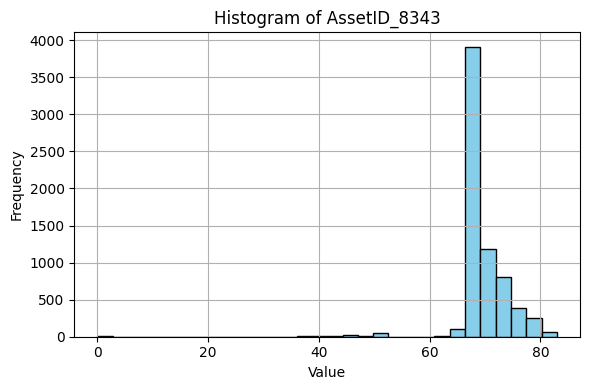

In [76]:
# رسم هیستوگرام برای AssetID_8343
plt.figure(figsize=(6, 4))
plt.hist(df1['AssetID_8343'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of AssetID_8343')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


In [77]:
from sklearn.preprocessing import StandardScaler

# انتخاب ستون‌ها برای استانداردسازی
data_to_scale = df1[['AssetID_8341', 'AssetID_8342', 'AssetID_8343', 'AssetID_8344',
       'AssetID_8346', 'AssetID_9286', 'AssetID_9287']]

# استانداردسازی داده‌ها
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_to_scale)

# تبدیل خروجی به دیتافریم با همان نام ستون‌ها
scaled_df = pd.DataFrame(scaled_data, columns=['AssetID_8341', 'AssetID_8342', 'AssetID_8343', 'AssetID_8344',
       'AssetID_8346', 'AssetID_9286', 'AssetID_9287'])

# نمایش ۵ ردیف اول
print(scaled_df.head())


   AssetID_8341  AssetID_8342  AssetID_8343  AssetID_8344  AssetID_8346  \
0      0.645358      0.844508     -0.543500      1.099605      0.837403   
1      1.681190           NaN     -5.514359      0.122380     -7.892331   
2      3.658687     -4.307744     -5.946608      0.122380     -7.892331   
3     -0.578808     -4.307744     -6.162732      0.122380     -7.892331   
4     -0.202141     -4.307744     -6.378857      0.122380     -7.892331   

   AssetID_9286  AssetID_9287  
0      0.801198      0.037813  
1     -0.170950      0.154200  
2     -0.170950      0.137573  
3     -0.170950      0.137573  
4     -0.170950      0.137573  


In [78]:
scaled_df_clean = scaled_df.dropna()

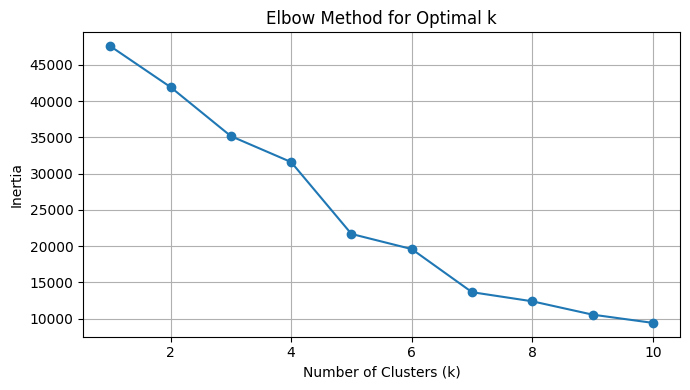

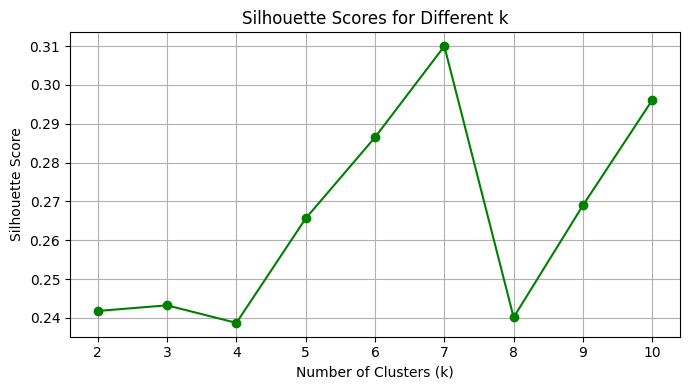

In [79]:
X = scaled_df_clean[['AssetID_8341', 'AssetID_8342', 'AssetID_8343', 'AssetID_8344',
       'AssetID_8346', 'AssetID_9286', 'AssetID_9287']]

# Elbow Method
inertias = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()

# Silhouette Scores
silhouette_scores = []
k_range_sil = range(2, 11)
for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(7, 4))
plt.plot(k_range_sil, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.show()


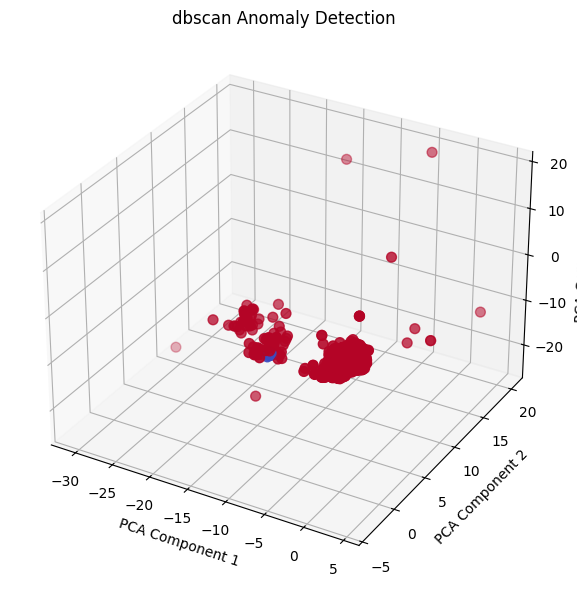

In [80]:
# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.6, min_samples=9)
labels = dbscan.fit_predict(scaled_df_clean)

# کاهش ابعاد داده‌ها به سه مؤلفه اصلی با PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(scaled_df_clean)

# رسم داده‌ها با رنگ‌بندی بر اساس برچسب‌های LOF در فضای سه‌بعدی
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    pca_result[:, 2],
    c=[0 if label == 1 else 1 for label in labels],  # 0 = normal, 1 = abnormal
    cmap='coolwarm',
    s=50
)

ax.set_title('dbscan Anomaly Detection')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
plt.tight_layout()
plt.show()


In [81]:
from sklearn.metrics import pairwise_distances_argmin_min
import numpy as np
import pandas as pd

# نقاط نرمال (label = 0)
normal_points = scaled_df_clean[labels != -1]
# نقاط غیرعادی (label = -1)
anomaly_indices = scaled_df_clean.index[labels == -1]
anomalies = scaled_df_clean.loc[anomaly_indices]


# محاسبه مرکز ثقل خوشه‌ها
unique_labels = set(labels) - {-1}
centroids = np.array([scaled_df_clean[labels == label].mean(axis=0) for label in unique_labels])

# محاسبه فاصله هر anomaly از نزدیک‌ترین مرکز خوشه
_, distances = pairwise_distances_argmin_min(anomalies, centroids)

# انتخاب مهم‌ترین موارد غیرعادی بر اساس بیشترین فاصله
top_n = 10
top_anomalies_idx_in_anomalies = distances.argsort()[::-1][:top_n]
important_anomalies = anomalies.iloc[top_anomalies_idx_in_anomalies]

# بازگردانی مقادیر اصلی از حالت نرمال‌شده
important_anomalies_original = scaler.inverse_transform(important_anomalies)

# تبدیل به دیتافریم با ستون‌های اصلی و اضافه کردن فاصله از مرکز خوشه
important_anomalies_df = pd.DataFrame(
    important_anomalies_original,
    columns=scaled_df_clean.columns, # Use scaled_df_clean.columns as anomalies is derived from it
    index=important_anomalies.index
)
important_anomalies_df['distance_from_centroid'] = distances[top_anomalies_idx_in_anomalies]


# نمایش خروجی نهایی
print(important_anomalies_df)

      AssetID_8341  AssetID_8342  AssetID_8343  AssetID_8344  AssetID_8346  \
910           0.38          12.1         70.00        -210.0           7.2   
6             0.18          10.8         35.00        -200.0           7.5   
276           0.00           0.0          0.00           0.0           0.0   
6748          0.13           1.7         70.00        -222.0           7.1   
961           0.47          12.1         70.00         225.0           7.1   
1121          2.00          12.1         70.00        -220.0           7.2   
209           0.16          12.0         72.00          74.0           7.0   
208           0.16          12.0         72.00          74.0           7.0   
135           0.04          12.0          0.04        -200.0           7.0   
2225          0.16          12.2          0.67        -240.0           7.2   

      AssetID_9286  AssetID_9287  distance_from_centroid  
910            7.5         38.00               61.031569  
6              0.0     

In [82]:
from sklearn.metrics import pairwise_distances_argmin_min
import numpy as np
import pandas as pd

# استخراج نقاط غیرعادی
anomalies = scaled_df_clean[labels == -1]

# اضافه کردن برچسب خوشه به دیتافریم استانداردشده
scaled_df_clean['dbscan_label'] = labels

# انتخاب فقط ستون‌های عددی برای محاسبه مرکز ثقل
numeric_cols = scaled_df_clean.select_dtypes(include=np.number).columns.tolist()
# حذف ستون های برچسب گذاری که عددی هستند اما برای خوشه بندی استفاده نشده اند
if 'dbscan_label' in numeric_cols:
    numeric_cols.remove('dbscan_label')
if 'anomaly_label' in numeric_cols:
    numeric_cols.remove('anomaly_label')


# محاسبه مرکز ثقل خوشه‌ها (بدون در نظر گرفتن نقاط غیرعادی)
unique_labels = set(labels) - {-1}
centroids = np.array([scaled_df_clean[scaled_df_clean['dbscan_label'] == label][numeric_cols].mean(axis=0) for label in unique_labels])


# محاسبه فاصله هر anomaly از نزدیک‌ترین مرکز خوشه
# اطمینان از اینکه anomalies فقط شامل ستون‌های عددی است
anomalies_numeric = anomalies[numeric_cols]
_, distances = pairwise_distances_argmin_min(anomalies_numeric, centroids)


# مرتب‌سازی بر اساس فاصله (نزولی)
sorted_idx = distances.argsort()[::-1]
sorted_anomalies_scaled = anomalies.iloc[sorted_idx]
sorted_distances = distances[sorted_idx]

# بازگردانی مقادیر اصلی از حالت نرمال‌شده
# اطمینان از اینکه anomalies_original فقط شامل ستون‌های عددی است
anomalies_original_numeric = scaler.inverse_transform(anomalies[numeric_cols])

# ساخت دیتافریم نهایی با مقادیر اصلی و فاصله از مرکز خوشه
anomalies_df = pd.DataFrame(
    anomalies_original_numeric,
    columns=numeric_cols, # استفاده از نام ستون های عددی
    index=sorted_anomalies_scaled.index # استفاده از ایندکس نمونه‌های مرتب شده
)
anomalies_df['distance_from_centroid'] = sorted_distances

# نمایش خروجی
print(anomalies_df)

      AssetID_8341  AssetID_8342  AssetID_8343  AssetID_8344  AssetID_8346  \
910           0.24          12.3          67.0        -200.0           7.8   
6             0.56          10.7          42.0        -220.0           0.0   
276           0.11          10.7          41.0        -220.0           0.0   
6748          0.15          10.7          40.0        -220.0           0.0   
961           0.18          10.7          36.0        -230.0           0.0   
...            ...           ...           ...           ...           ...   
1569          0.17          12.0          71.0        -200.0           7.7   
1568          0.17          12.0          71.0        -200.0           7.7   
1567          0.12          11.7          70.0        -220.0           7.1   
1570          0.13           1.7          70.0        -222.0           7.1   
1563          0.25          11.6           7.0        -220.0           7.1   

      AssetID_9286  AssetID_9287  distance_from_centroid  
910 

In [83]:
# انتخاب مواردی که فاصله‌شان از مرکز خوشه‌ها بیشتر از آستانه مشخصی است
threshold = np.percentile(distances, 90)  # مثلاً ۱۰٪ بالاترین فاصله‌ها
selected_idx = np.where(distances > threshold)[0]
selected_anomalies = anomalies.iloc[selected_idx]
selected_anomalies_original = scaler.inverse_transform(selected_anomalies)

selected_df = pd.DataFrame(
    selected_anomalies_original,
    columns=data_to_scale.columns, # Use the original numerical column names
    index=selected_anomalies.index
)
selected_df['distance_from_centroid'] = distances[selected_idx]

print("Selected anomalies based on distance threshold:")
print(selected_df)

Selected anomalies based on distance threshold:
      AssetID_8341  AssetID_8342  AssetID_8343  AssetID_8344  AssetID_8346  \
6             0.18         10.80         35.00        -200.0           7.5   
135           0.04         12.00          0.04        -200.0           7.0   
208           0.16         12.00         72.00          74.0           7.0   
209           0.16         12.00         72.00          74.0           7.0   
276           0.00          0.00          0.00           0.0           0.0   
910           0.38         12.10         70.00        -210.0           7.2   
961           0.47         12.10         70.00         225.0           7.1   
1121          2.00         12.10         70.00        -220.0           7.2   
1571          0.28         11.00         53.00        -250.0           7.0   
1572          0.23         11.20         47.00        -250.0           7.0   
1577          0.40         11.00         45.00        -260.0           0.0   
1578          0.

In [84]:
anomalies_df.to_excel('all_anomalies_sorted.xlsx')
# یا
anomalies_df.to_html('all_anomalies_sorted.html')


In [85]:
import pandas as pd

# بازگردانی مقادیر اصلی از حالت نرمالایز
important_anomalies_original = scaler.inverse_transform(important_anomalies)

# تبدیل به دیتافریم با ستون‌های اصلی
important_anomalies_df = pd.DataFrame(
    important_anomalies_original,
    columns=data_to_scale.columns, # Use original column names
    index=important_anomalies.index
)

# نمایش خروجی
print(important_anomalies_df)

      AssetID_8341  AssetID_8342  AssetID_8343  AssetID_8344  AssetID_8346  \
910           0.38          12.1         70.00        -210.0           7.2   
6             0.18          10.8         35.00        -200.0           7.5   
276           0.00           0.0          0.00           0.0           0.0   
6748          0.13           1.7         70.00        -222.0           7.1   
961           0.47          12.1         70.00         225.0           7.1   
1121          2.00          12.1         70.00        -220.0           7.2   
209           0.16          12.0         72.00          74.0           7.0   
208           0.16          12.0         72.00          74.0           7.0   
135           0.04          12.0          0.04        -200.0           7.0   
2225          0.16          12.2          0.67        -240.0           7.2   

      AssetID_9286  AssetID_9287  
910            7.5         38.00  
6              0.0         34.00  
276            0.0          0.00  
6

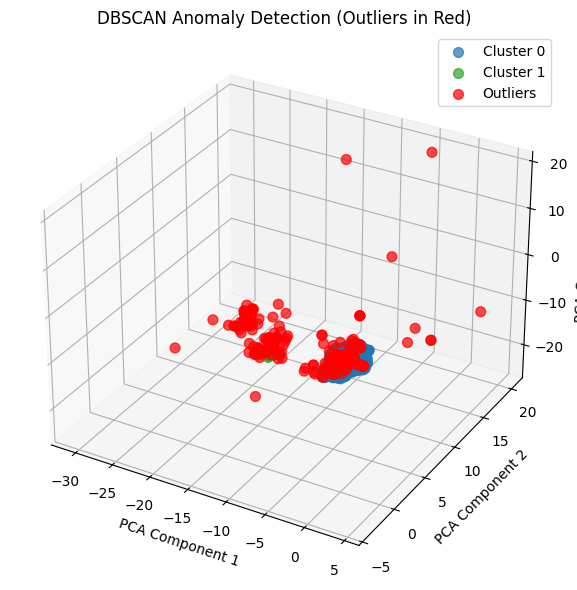

In [86]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.6, min_samples=9)
labels = dbscan.fit_predict(scaled_df_clean)

# کاهش ابعاد داده‌ها به سه مؤلفه اصلی با PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(scaled_df_clean)

# تعریف رنگ‌ها: خوشه‌ها با رنگ‌های مختلف، نویز (outliers) با رنگ قرمز
colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:brown', 'tab:pink']
outlier_color = 'red'

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for label in set(labels):
    color = outlier_color if label == -1 else colors[label % len(colors)]
    mask = labels == label
    ax.scatter(
        pca_result[mask, 0],
        pca_result[mask, 1],
        pca_result[mask, 2],
        c=color,
        label=f'Cluster {label}' if label != -1 else 'Outliers',
        s=50,
        alpha=0.7
    )

ax.set_title('DBSCAN Anomaly Detection (Outliers in Red)')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.legend()
plt.tight_layout()
plt.show()


In [87]:
# !pip freeze > requirements.txt

Normal points: 6623
Outliers: 213


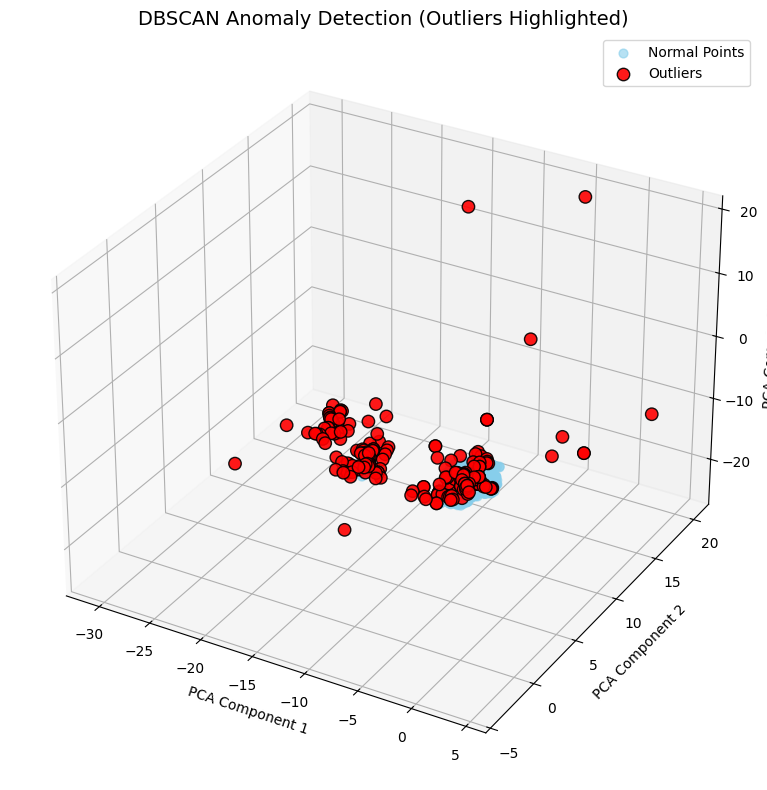

In [88]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.6, min_samples=9)
labels = dbscan.fit_predict(scaled_df_clean)

# شمارش نقاط نرمال و نقاط پرت
n_outliers = np.sum(labels == -1)
n_core = np.sum(labels != -1)
print(f"Normal points: {n_core}")
print(f"Outliers: {n_outliers}")

# کاهش ابعاد داده‌ها به سه مؤلفه اصلی با PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(scaled_df_clean)

# رسم داده‌ها با رنگ‌بندی و جداسازی واضح
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# نقاط نرمال (خوشه‌ها)
core_mask = labels != -1
ax.scatter(
    pca_result[core_mask, 0],
    pca_result[core_mask, 1],
    pca_result[core_mask, 2],
    c='skyblue',
    label='Normal Points',
    s=40,
    alpha=0.6
)

# نقاط پرت (outliers)
outlier_mask = labels == -1
ax.scatter(
    pca_result[outlier_mask, 0],
    pca_result[outlier_mask, 1],
    pca_result[outlier_mask, 2],
    c='red',
    label='Outliers',
    s=80,
    alpha=0.9,
    edgecolors='black'
)

ax.set_title('DBSCAN Anomaly Detection (Outliers Highlighted)', fontsize=14)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.legend()
plt.tight_layout()
plt.show()


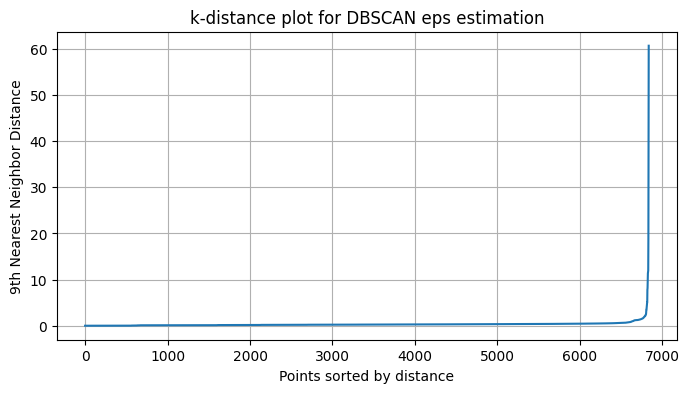

In [89]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# Choose min_samples (e.g., 6)
min_samples = 9
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(scaled_df_clean)
distances, indices = neighbors_fit.kneighbors(scaled_df_clean)

# Sort and plot the k-distances
k_distances = np.sort(distances[:, -1])
plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title('k-distance plot for DBSCAN eps estimation')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
plt.grid(True)
plt.show()


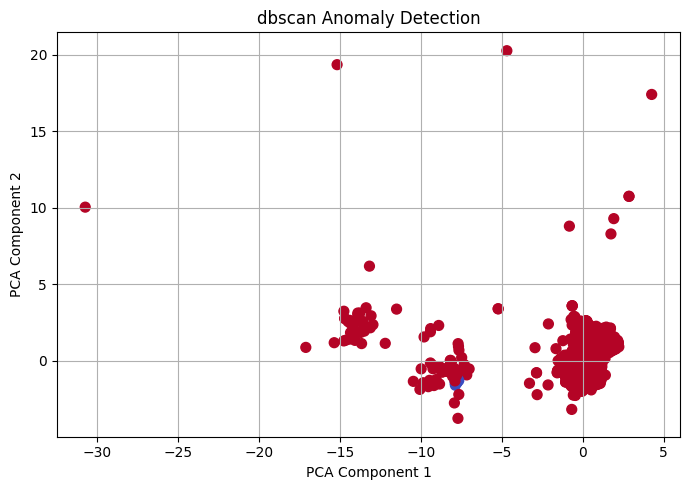

درصد ناهنجاری‌ها: 3.12%
تعداد داده‌ها در هر خوشه:
Noise (abnormal): 213 مورد
Cluster 0: 6614 مورد
Cluster 1: 9 مورد


In [90]:
# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.6, min_samples=9)
labels = dbscan.fit_predict(scaled_df_clean)

# کاهش ابعاد داده‌ها به دو مؤلفه اصلی با PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df_clean)

# رسم داده‌ها با رنگ‌بندی بر اساس برچسب‌های LOF
plt.figure(figsize=(7, 5))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=[0 if label == 1 else 1 for label in labels],  # 0 = normal, 1 = abnormal
    cmap='coolwarm',
    s=50
)
plt.title('dbscan Anomaly Detection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()

num_abnormal = np.sum(labels == -1)
num_total = len(labels)
print(f"درصد ناهنجاری‌ها: {100 * num_abnormal / num_total:.2f}%")

# ساخت یک سری از برچسب‌های خوشه
cluster_series = pd.Series(labels)

# شمارش تعداد اعضای هر خوشه
cluster_counts = cluster_series.value_counts().sort_index()

# نمایش نتایج
print("تعداد داده‌ها در هر خوشه:")
for cluster_id, count in cluster_counts.items():
    label = f"Cluster {cluster_id}" if cluster_id != -1 else "Noise (abnormal)"
    print(f"{label}: {count} مورد")


In [91]:
from sklearn.metrics import davies_bouldin_score
from sklearn.cluster import DBSCAN
import numpy as np

best_score = float("inf")  # چون مقدار کمتر بهتره
best_params = None

for eps in np.arange(0.3, 1.2, 0.1):
    for min_samples in range(4, 10):
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(scaled_df_clean)
        labels = db.labels_

        unique_labels = set(labels)
        if -1 in unique_labels:
            unique_labels.remove(-1)
        if len(unique_labels) > 1:
            # حذف نقاط نویز برای محاسبه شاخص
            core_samples_mask = labels != -1
            core_labels = labels[core_samples_mask]
            scaled_df_clean_filtered = scaled_df_clean[core_samples_mask]

            score = davies_bouldin_score(scaled_df_clean_filtered, core_labels)
            if score < best_score:
                best_score = score
                best_params = (eps, min_samples)
            print(f"eps={eps:.1f}, min_samples={min_samples} → DB Index={score:.3f}")

print(f"\nBest Davies-Bouldin Index: {best_score:.3f}")
print(f"Optimal eps: {best_params[0]:.1f}, min_samples: {best_params[1]}")


eps=0.3, min_samples=4 → DB Index=1.088
eps=0.3, min_samples=5 → DB Index=1.188
eps=0.3, min_samples=6 → DB Index=1.205
eps=0.3, min_samples=7 → DB Index=1.171
eps=0.3, min_samples=8 → DB Index=1.166
eps=0.3, min_samples=9 → DB Index=1.116
eps=0.4, min_samples=4 → DB Index=0.741
eps=0.4, min_samples=5 → DB Index=0.770
eps=0.4, min_samples=6 → DB Index=1.145
eps=0.4, min_samples=7 → DB Index=1.164
eps=0.4, min_samples=8 → DB Index=1.311
eps=0.4, min_samples=9 → DB Index=1.030
eps=0.5, min_samples=4 → DB Index=0.626
eps=0.5, min_samples=5 → DB Index=0.691
eps=0.5, min_samples=6 → DB Index=0.578
eps=0.5, min_samples=7 → DB Index=0.772
eps=0.5, min_samples=8 → DB Index=0.802
eps=0.5, min_samples=9 → DB Index=0.801
eps=0.6, min_samples=4 → DB Index=0.590
eps=0.6, min_samples=5 → DB Index=0.431
eps=0.6, min_samples=6 → DB Index=0.425
eps=0.6, min_samples=7 → DB Index=0.364
eps=0.6, min_samples=8 → DB Index=0.228
eps=0.6, min_samples=9 → DB Index=0.198
eps=0.7, min_samples=4 → DB Index=0.640


In [92]:
from sklearn.metrics import davies_bouldin_score
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import numpy as np

# Re-perform DBSCAN and PCA within this cell
dbscan = DBSCAN(eps=0.7, min_samples=4) # Using the best params found earlier
labels = dbscan.fit_predict(scaled_df_clean)

# Reduce dimensions with PCA for visualization and analysis
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df_clean)

# Filter for normal data (labels ≠ -1)
mask = labels != -1
pca_filtered = pca_result[mask]
labels_filtered = labels[mask]

# Calculate Davies-Bouldin Index on the normal data (excluding noise points)
if len(np.unique(labels_filtered)) > 1: # Ensure there's more than one cluster
    db_index = davies_bouldin_score(pca_filtered, labels_filtered)

    # Display the index value
    print(f"Davies-Bouldin Index for DBSCAN clusters (excluding noise points): {db_index:.2f}")
else:
    print("Cannot calculate Davies-Bouldin Index: Less than two clusters found after removing noise.")

Davies-Bouldin Index for DBSCAN clusters (excluding noise points): 1.06


In [93]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

best_score = -1
best_params = None

for eps in [0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,1.2]:
    for min_samples in [3,4,5,6,9]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(scaled_df_clean)

        # فقط نقاط نرمال را برای سیلوئت در نظر بگیر
        mask = labels != -1
        if len(set(labels[mask])) > 1:
            score = silhouette_score(scaled_df_clean[mask], labels[mask])
            print(f"eps={eps}, min_samples={min_samples} → silhouette={score:.3f}")
            if score > best_score:
                best_score = score
                best_params = (eps, min_samples)

print(f"\n✅ بهترین ترکیب: eps={best_params[0]}, min_samples={best_params[1]} با نمره سیلوئت {best_score:.3f}")


eps=0.3, min_samples=3 → silhouette=-0.155
eps=0.3, min_samples=4 → silhouette=-0.134
eps=0.3, min_samples=5 → silhouette=-0.094
eps=0.3, min_samples=6 → silhouette=-0.046
eps=0.3, min_samples=9 → silhouette=0.042
eps=0.4, min_samples=3 → silhouette=-0.428
eps=0.4, min_samples=4 → silhouette=-0.383
eps=0.4, min_samples=5 → silhouette=-0.303
eps=0.4, min_samples=6 → silhouette=-0.293
eps=0.4, min_samples=9 → silhouette=-0.029
eps=0.5, min_samples=3 → silhouette=-0.309
eps=0.5, min_samples=4 → silhouette=-0.177
eps=0.5, min_samples=5 → silhouette=-0.081
eps=0.5, min_samples=6 → silhouette=0.010
eps=0.5, min_samples=9 → silhouette=-0.097
eps=0.6, min_samples=3 → silhouette=-0.149
eps=0.6, min_samples=4 → silhouette=-0.043
eps=0.6, min_samples=5 → silhouette=0.334
eps=0.6, min_samples=6 → silhouette=0.334
eps=0.6, min_samples=9 → silhouette=0.781
eps=0.7, min_samples=3 → silhouette=-0.152
eps=0.7, min_samples=4 → silhouette=-0.135
eps=0.7, min_samples=5 → silhouette=0.035
eps=0.7, min_samp

In [94]:
from sklearn.metrics import calinski_harabasz_score

best_score = -1
best_params = None

for eps in np.arange(0.3, 1.2, 0.1):
    for min_samples in range(4, 10):
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(scaled_df_clean)
        labels = db.labels_

        unique_labels = set(labels)
        if -1 in unique_labels:
            unique_labels.remove(-1)
        if len(unique_labels) > 1:
            # حذف نقاط نویز برای محاسبه شاخص
            core_samples_mask = labels != -1
            core_labels = labels[core_samples_mask]
            scaled_df_clean_filtered = scaled_df_clean[core_samples_mask]

            score = calinski_harabasz_score(scaled_df_clean_filtered, core_labels)
            if score > best_score:
                best_score = score
                best_params = (eps, min_samples)
            print(f"eps={eps:.1f}, min_samples={min_samples} → CH Score={score:.2f}")

print(f"\nBest Calinski-Harabasz Score: {best_score:.2f}")
print(f"Optimal eps: {best_params[0]:.1f}, min_samples: {best_params[1]}")


eps=0.3, min_samples=4 → CH Score=274.30
eps=0.3, min_samples=5 → CH Score=316.24
eps=0.3, min_samples=6 → CH Score=361.12
eps=0.3, min_samples=7 → CH Score=427.46
eps=0.3, min_samples=8 → CH Score=467.07
eps=0.3, min_samples=9 → CH Score=478.42
eps=0.4, min_samples=4 → CH Score=66.67
eps=0.4, min_samples=5 → CH Score=26.61
eps=0.4, min_samples=6 → CH Score=30.92
eps=0.4, min_samples=7 → CH Score=33.95
eps=0.4, min_samples=8 → CH Score=37.40
eps=0.4, min_samples=9 → CH Score=442.30
eps=0.5, min_samples=4 → CH Score=129.62
eps=0.5, min_samples=5 → CH Score=112.95
eps=0.5, min_samples=6 → CH Score=100.08
eps=0.5, min_samples=7 → CH Score=24.57
eps=0.5, min_samples=8 → CH Score=22.16
eps=0.5, min_samples=9 → CH Score=19.94
eps=0.6, min_samples=4 → CH Score=184.75
eps=0.6, min_samples=5 → CH Score=325.18
eps=0.6, min_samples=6 → CH Score=310.22
eps=0.6, min_samples=7 → CH Score=316.32
eps=0.6, min_samples=8 → CH Score=310.92
eps=0.6, min_samples=9 → CH Score=314.66
eps=0.7, min_samples=4 →

In [95]:
# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.6, min_samples=9) # Using the best params found earlier
labels = dbscan.fit_predict(scaled_df_clean)

# اضافه کردن برچسب خوشه به دیتافریم استانداردشده
scaled_df_clean['dbscan_label'] = labels

# افزودن برچسب DBSCAN به دیتافریم اصلی با استفاده از ایندکس
df1 = df1.merge(scaled_df_clean[['dbscan_label']], left_index=True, right_index=True, how='left')

# فیلتر کردن نمونه‌های غیرنرمال (برچسب -1)
abnormal_df = df1[df1['dbscan_label'] == -1]

# انتخاب ۱۰ نمونه تصادفی از موارد غیرنرمال
abnormal_sample = abnormal_df.sample(n=10, random_state=42).reset_index(drop=True)

# نمایش جدول نهایی
print("🔍 ۱۰ نمونه از داده‌های غیرنرمال شناسایی‌شده توسط DBSCAN (با مقادیر واقعی):")
print(abnormal_sample)

🔍 ۱۰ نمونه از داده‌های غیرنرمال شناسایی‌شده توسط DBSCAN (با مقادیر واقعی):
   AssetID_8346  AssetID_9286  AssetID_8341  AssetID_9287  AssetID_8343  \
0           0.0           0.0          0.23          1.48          44.0   
1           7.2           7.6          0.23          1.35          70.0   
2           0.0           7.4          0.37          1.42          45.0   
3           6.2           7.6          0.22          1.35          70.0   
4           0.0           7.4          0.42          1.40          46.0   
5           7.0           7.5          0.32          1.31          68.0   
6           0.0           7.4          0.39          1.42          50.0   
7           0.0           0.0          0.22          1.45          48.0   
8           0.0           7.4          0.12          1.50          45.0   
9           7.1           7.5          0.34          1.35          72.0   

   AssetID_8344  AssetID_8342                date  dbscan_label  
0        -240.0          11.3 202

In [96]:
from sklearn.cluster import DBSCAN
import pandas as pd

# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.6, min_samples=9)
labels = dbscan.fit_predict(scaled_df_clean)

# افزودن برچسب خوشه به دیتافریم استانداردشده
scaled_df_clean['dbscan_label'] = labels

# افزودن برچسب DBSCAN به دیتافریم اصلی با استفاده از ایندکس
df1 = df1.merge(scaled_df_clean[['dbscan_label']], left_index=True, right_index=True, how='left', suffixes=('', '_y'))

# حذف ستون‌های تکراری در صورت وجود
df1 = df1.loc[:, ~df1.columns.duplicated()]

# فیلتر کردن نمونه‌های غیرنرمال (برچسب -1)
abnormal_df = df1[df1['dbscan_label'] == -1]

# انتخاب ۱۰ نمونه تصادفی از موارد غیرنرمال
abnormal_sample = abnormal_df.sample(n=10, random_state=42).reset_index(drop=True)

# حذف ستون برچسب DBSCAN
abnormal_sample = abnormal_sample.drop(columns=['dbscan_label'])

# نمایش جدول نهایی به‌صورت یکپارچه
pd.set_option('display.max_columns', None)  # نمایش تمام ستون‌ها
pd.set_option('display.width', None)        # جلوگیری از شکستن خطوط
print("🔍 ۱۰ نمونه از داده‌های غیرنرمال شناسایی‌شده توسط DBSCAN (با مقادیر واقعی):")
print(abnormal_sample)


🔍 ۱۰ نمونه از داده‌های غیرنرمال شناسایی‌شده توسط DBSCAN (با مقادیر واقعی):
   AssetID_8346  AssetID_9286  AssetID_8341  AssetID_9287  AssetID_8343  \
0           0.0           0.0          0.23          1.48          44.0   
1           7.2           7.6          0.23          1.35          70.0   
2           0.0           7.4          0.37          1.42          45.0   
3           6.2           7.6          0.22          1.35          70.0   
4           0.0           7.4          0.42          1.40          46.0   
5           7.0           7.5          0.32          1.31          68.0   
6           0.0           7.4          0.39          1.42          50.0   
7           0.0           0.0          0.22          1.45          48.0   
8           0.0           7.4          0.12          1.50          45.0   
9           7.1           7.5          0.34          1.35          72.0   

   AssetID_8344  AssetID_8342                date  dbscan_label_y  
0        -240.0          11.3 2

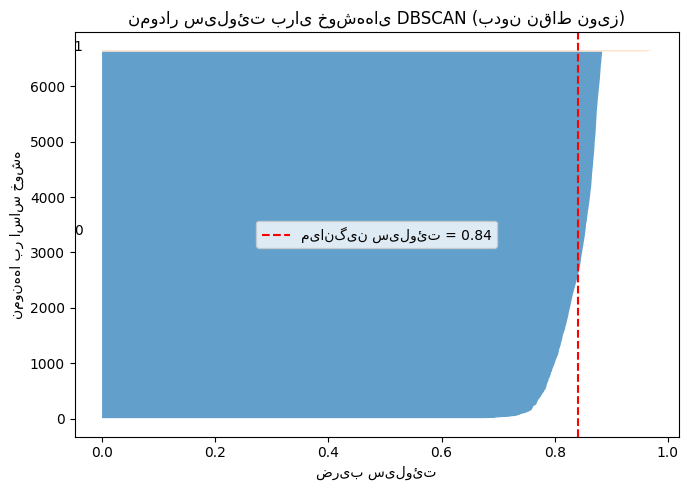

In [97]:
# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.6, min_samples=9)
labels = dbscan.fit_predict(scaled_df_clean)

# کاهش ابعاد با PCA برای نمایش و تحلیل
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df_clean)

# فیلتر کردن داده‌های نرمال (برچسب ≠ -1)
mask = labels != -1
pca_filtered = pca_result[mask]
labels_filtered = labels[mask]

# محاسبه نمرات سیلوئت
silhouette_vals = silhouette_samples(pca_filtered, labels_filtered)
silhouette_avg = silhouette_score(pca_filtered, labels_filtered)

# رسم نمودار سیلوئت
plt.figure(figsize=(7, 5))
y_lower = 10
for i in np.unique(labels_filtered):
    ith_cluster_silhouette_vals = silhouette_vals[labels_filtered == i]
    ith_cluster_silhouette_vals.sort()
    size_cluster_i = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_vals,
        alpha=0.7
    )
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"میانگین سیلوئت = {silhouette_avg:.2f}")
plt.xlabel("ضریب سیلوئت")
plt.ylabel("نمونه‌ها بر اساس خوشه")
plt.title("نمودار سیلوئت برای خوشه‌های DBSCAN (بدون نقاط نویز)")
plt.legend()
plt.tight_layout()
plt.show()

In [98]:
from sklearn.metrics import pairwise_distances

# نقاط نرمال (خوشه‌ای)
normal_points = scaled_df_clean[labels != -1]
# نقاط غیرعادی
outliers = scaled_df_clean[labels == -1]

# فاصله هر نقطه غیرعادی تا نزدیک‌ترین نقطه نرمال
distances = pairwise_distances(outliers, normal_points)
min_distances = distances.min(axis=1)


In [99]:
# ساخت DataFrame برای نقاط غیرعادی و فاصله‌ها
outlier_df = pd.DataFrame(outliers)
outlier_df["min_distance_to_cluster"] = min_distances

# انتخاب تصادفی ۱۰ نقطه
np.random.seed(42)  # برای reproducibility
sampled_outliers = outlier_df.sample(n=10)

# مرتب‌سازی بر اساس فاصله (شدت غیرعادی بودن)
sampled_outliers_sorted = sampled_outliers.sort_values(by="min_distance_to_cluster", ascending=False)

# نمایش جدول
print("\n🔎 بررسی ۱۰ نقطه غیرعادی انتخاب‌شده:")
print(sampled_outliers_sorted[["min_distance_to_cluster"]])



🔎 بررسی ۱۰ نقطه غیرعادی انتخاب‌شده:
      min_distance_to_cluster
10                  12.281237
1596                12.176717
18                   3.364573
1658                 3.244759
1576                 2.969621
1585                 2.369804
1652                 1.406781
5062                 1.342261
5096                 1.177465
2538                 1.073586


In [100]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, novelty=False)
lof_scores = -lof.fit_predict(outliers)  # نمره LOF (بزرگ‌تر = غیرعادی‌تر)
lof_factors = -lof.negative_outlier_factor_

In [101]:
# ساخت DataFrame برای نقاط نویز و نمره LOF
lof_df = pd.DataFrame(outliers)
lof_df["LOF_score"] = lof_factors  # مقدار LOF (بزرگ‌تر = غیرعادی‌تر)

# انتخاب تصادفی ۱۰ نقطه
np.random.seed(42)  # برای reproducibility
sampled_lof = lof_df.sample(n=10)

# مرتب‌سازی بر اساس نمره LOF
sampled_lof_sorted = sampled_lof.sort_values(by="LOF_score", ascending=False)

# نمایش جدول
print("\n🔎 بررسی ۱۰ نقطه غیرعادی با LOF:")
print(sampled_lof_sorted[["LOF_score"]])



🔎 بررسی ۱۰ نقطه غیرعادی با LOF:
      LOF_score
18     1.253773
1585   1.145252
1658   1.032053
1652   1.030919
1576   0.998124
2538   0.994772
10     0.986293
5096   0.976649
5062   0.972796
1596   0.968903


تراکم محلی (Local Density)
نقاطی که در ناحیه‌ای با تراکم بسیار پایین قرار دارن، احتمالاً غیرعادی‌تر هستن.

k-distance یا kernel density estimation

In [102]:
# انتخاب تعداد همسایه‌ها (k)
k = 10

# مدل همسایگی روی نقاط غیرعادی
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(outliers)

# محاسبه فاصله‌ها تا k همسایه
distances, indices = nbrs.kneighbors(outliers)

# فاصله تا k‌امین همسایه (یعنی فاصله کم‌تراکم‌ترین نقطه اطراف)
k_distances = distances[:, -1]

# ساخت DataFrame برای تحلیل
density_df = pd.DataFrame(outliers)
density_df["k_distance"] = k_distances

# انتخاب تصادفی ۱۰ نقطه
np.random.seed(42)
sampled_density = density_df.sample(n=10)

# مرتب‌سازی بر اساس فاصله (کم‌تراکم‌ترین اول)
sampled_density_sorted = sampled_density.sort_values(by="k_distance", ascending=False)

# نمایش جدول
print("\n🔎 بررسی ۱۰ نقطه غیرعادی با k-distance:")
print(sampled_density_sorted[["k_distance"]])



🔎 بررسی ۱۰ نقطه غیرعادی با k-distance:
      k_distance
18      2.062162
1652    1.845803
5062    1.731557
1585    1.633794
2538    1.576607
5096    1.521314
10      1.458923
1596    1.250214
1576    1.061304
1658    0.993164


ستون k_distance نشون می‌ده که هر نقطه چقدر از همسایه‌های خودش فاصله داره.

مقدار بالا → تراکم پایین → احتمال غیرعادی بودن بیشتر.

(مثلاً فقط نقاط با k_distance > 1.5 رو به‌عنوان خرابی بحرانی علامت بزنیم).

In [103]:
from sklearn.preprocessing import MinMaxScaler

# نقاط نرمال و غیرعادی
normal_points = scaled_df_clean[labels != -1]
outliers = scaled_df_clean[labels == -1]

# 1. فاصله از نزدیک‌ترین نقطه نرمال
distances = pairwise_distances(outliers, normal_points)
min_distances = distances.min(axis=1)

# 2. نمره LOF
lof = LocalOutlierFactor(n_neighbors=20, novelty=False)
lof.fit(outliers)
lof_scores = -lof.negative_outlier_factor_

# 3. k-distance (تراکم محلی)
k = 10
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(outliers)
k_distances = nbrs.kneighbors(outliers)[0][:, -1]

# ساخت DataFrame
ensemble_df = pd.DataFrame(outliers)
ensemble_df["distance_to_cluster"] = min_distances
ensemble_df["lof_score"] = lof_scores
ensemble_df["k_distance"] = k_distances

# نرمال‌سازی هر شاخص بین 0 و 1
scaler = MinMaxScaler()
normalized = scaler.fit_transform(ensemble_df[["distance_to_cluster", "lof_score", "k_distance"]])
ensemble_df[["norm_dist", "norm_lof", "norm_kdist"]] = normalized

# محاسبه نمره ترکیبی
ensemble_df["ensemble_score"] = ensemble_df[["norm_dist", "norm_lof", "norm_kdist"]].mean(axis=1)

# انتخاب تصادفی ۱۰ نقطه و مرتب‌سازی بر اساس نمره ترکیبی
np.random.seed(42)
sampled = ensemble_df.sample(n=10)
sampled_sorted = sampled.sort_values(by="ensemble_score", ascending=False)

# نمایش جدول نهایی
print("\n🔎 بررسی ۱۰ نقطه غیرعادی با نمره ترکیبی:")
print(sampled_sorted[["distance_to_cluster", "lof_score", "k_distance", "ensemble_score"]])



🔎 بررسی ۱۰ نقطه غیرعادی با نمره ترکیبی:
      distance_to_cluster  lof_score  k_distance  ensemble_score
10              12.281237   0.986293    1.458923        0.068054
1596            12.176717   0.968903    1.250214        0.066062
18               3.364573   1.253773    2.062162        0.025401
1585             2.369804   1.145252    1.633794        0.015895
1658             3.244759   1.032053    0.993164        0.015602
1576             2.969621   0.998124    1.061304        0.013950
1652             1.406781   1.030919    1.845803        0.010030
5062             1.342261   0.972796    1.731557        0.008195
5096             1.177465   0.976649    1.521314        0.006165
2538             1.073586   0.994772    1.576607        0.006152


فاصله از خوشه (هرچه بیشتر → غیرعادی‌تر)

نمره LOF (هرچه بیشتر → غیرعادی‌تر)

k-distance یا تراکم محلی (هرچه بیشتر → غیرعادی‌تر)

برای این کار، هر شاخص رو نرمال‌سازی می‌کنیم (بین 0 و 1)، بعد میانگین می‌گیریم تا نمره نهایی به دست بیاد. سپس ۱۰ نقطه غیرعادی رو به‌صورت تصادفی انتخاب می‌کنیم و بر اساس این نمره ترکیبی رتبه‌بندی می‌کنیم.

In [104]:
# فرض بر اینه که ensemble_df قبلاً ساخته شده و شامل ستون ensemble_score هست

# محاسبه آستانه ۹۰ درصد بالا
threshold = np.percentile(ensemble_df["ensemble_score"], 90)

# رسم هیستوگرام
plt.figure(figsize=(8, 5))
plt.hist(ensemble_df["ensemble_score"], bins=30, color="skyblue", edgecolor="black")
plt.axvline(threshold, color="red", linestyle="--", label=f"آستانه ۹۰٪ = {threshold:.2f}")
plt.title("هیستوگرام نمره ترکیبی غیرعادی بودن")
plt.xlabel("نمره غیرعادی بودن")
plt.ylabel("تعداد نقاط")
plt.legend()
plt.tight_layout()
plt.savefig("ensemble_score_histogram.png")
plt.close()

# رسم boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(ensemble_df["ensemble_score"], vert=False)
plt.axvline(threshold, color="red", linestyle="--", label=f"آستانه ۹۰٪ = {threshold:.2f}")
plt.title("Boxplot نمره ترکیبی غیرعادی بودن")
plt.xlabel("نمره غیرعادی بودن")
plt.legend()
plt.tight_layout()
plt.savefig("ensemble_score_boxplot.png")
plt.close()

# استخراج نقاط بحرانی
critical_points = ensemble_df[ensemble_df["ensemble_score"] > threshold]

# ذخیره خروجی به CSV
critical_points.to_csv("critical_anomalies.csv", index=False)

print(f"✅ آستانه ۹۰٪ محاسبه شد: {threshold:.2f}")
print(f"📊 نمودارها ذخیره شدند: ensemble_score_histogram.png و ensemble_score_boxplot.png")
print(f"📁 نقاط بحرانی ذخیره شدند در: critical_anomalies.csv")


✅ آستانه ۹۰٪ محاسبه شد: 0.09
📊 نمودارها ذخیره شدند: ensemble_score_histogram.png و ensemble_score_boxplot.png
📁 نقاط بحرانی ذخیره شدند در: critical_anomalies.csv
